# Camera-pose alignment spike: tie-point correction for the real-WAC overlay

`image_generation.ipynb`'s Phase 6B overlay (the real, ISIS-processed WAC crop mapprojected onto
the basemap) used to be visibly not perfectly aligned with it. That turned out to be mostly a
ground-truth bug, not a camera-pose one: `isis_wac.run_spiceinit` hardcoded `shape=ellipsoid` for
every real-WAC cube, when the real fix was attaching ISIS's own real global lunar DEM
(`shape=user`) instead -- see `docs/plan.md`'s dated entry. That fix now lives in the main
pipeline (every real-WAC cube gets the real DEM by default), so this notebook no longer compares
DEM against ellipsoid -- there's nothing left running through the ellipsoid.

**On the back burner, not superseded** (the user's own framing, see `docs/plan.md`): the DEM fix
closed the specific gap visible on this candidate, but the capability this notebook exercises --
measuring real alignment statistics, independent of whether a correction actually gets applied --
stays valuable. There's no guarantee a future WAC product's initial SPICE-derived registration will
be this clean; this is exactly the tooling that would catch it if not.

**The options being compared, systematically**: every correction below varies along three axes --

- **projection**: `2D->2D` fits a correction directly between two already map-projected rasters
  (`src/trntest/pose_alignment.py`, no camera model involved at all) vs. `3D->2D` fits a correction
  to the actual camera pose, projecting a real 3D ground point through it to a 2D image pixel
  (`src/trntest/wac_camera_model.py` + `control_network.py`, real ISIS control points).
- **matcher**: `SIFT` (classical, Sobel-filtered) vs. `LightGlue` (learned DISK features + learned
  matcher -- more matches, real headroom for future low-texture EDRs SIFT might struggle on).
- **correction**: `uncorrected` (the raw match-implied offset, no fit at all) through increasingly
  flexible 2D models (`similarity` 4 DOF, `affine` 6 DOF, `homography` 8 DOF) to the one physically
  real correction, `6-DOF pose` (an actual camera exterior-orientation correction, fit against real
  ISIS control points, then baked back into the crop cube so ISIS's own unmodified `cam2map`
  reprojects it).

This notebook evaluates the same combinations of these three axes the original investigation did --
no new combinations added -- reported as one table (`results_df` below) instead of scattered
prints, with each blink overlay labeled by which table row it corresponds to. **Expect the overlays
to look similarly well-aligned and a bit boring now** -- that's the DEM fix working, not a wasted
notebook; a clean before/after here is itself useful confirmation, not just a null result.

In [1]:
import warnings

import numpy as np
import pandas as pd
import rasterio
from scipy.spatial.transform import Rotation

import trntest
from trntest import control_network, isis_wac, plotting, pose_alignment, tie_points, wac_camera_model

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
dataset.populate(limit=1)
entry = dataset[0]

# `entry.crop_result` carries ISIS's real global lunar DEM by default now (isis_wac.run_spiceinit) --
# no separate DEM-attachment step needed here anymore, unlike this notebook's earlier form.
wac_path = isis_wac.run_cam2map_for_crop(entry.crop_result, entry.dem_ortho_result, entry.per_image_config)
basemap_path = entry.dem_ortho_result.ortho
print("WAC mapprojected crop (DEM shape model):", wac_path)
print("Basemap ortho:", basemap_path)

results = []  # one dict per table row, appended right after each metric is computed below

ROI center (lon,lat deg): (np.float64(149.46655197308), np.float64(-67.438792511225)), bbox (local m): (-77968.62902772061, -76358.13650676086, 80482.79337766473, 77959.56536998769)
ROI size 1585x1543 px (~100.0 m/px)


WAC mapprojected crop (DEM shape model): /workspace/scratch/isis_wac/M1327210646CE/M1327210646CE.vis.cal.stitched.crop-cam2map.tif
Basemap ortho: /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc.tif


## Crop the basemap to the WAC's own footprint, and prepare both for matching

The basemap ortho covers a much larger area than the WAC crop's own real footprint -- cropping to
match (`pose_alignment.crop_to_footprint`, padded 15%) gives the feature matcher a far smaller,
more relevant search space; confirmed empirically to matter for match quality, not just compute.

Both `wac_path` and the basemap ortho are on the same ~100 m/px working grid (`config.
DEFAULT_DEM_TARGET_GSD_M`) -- but that's genuinely native resolution for the basemap
(`luna_wac_global`'s own ~100 m/px mosaic) and *not* for this WAC crop: `isis_wac.
run_cam2map_for_crop`'s `PIXRES=map` forces its output onto that same 100 m/px grid regardless of
the camera's own real resolution at this pose, which a direct `cam2map PIXRES=camera` probe found
to be ~184 m/px for this candidate (~1.8x coarser -- see `docs/history.md`'s dated entry). Matching
SIFT keypoints on the interpolated-not-actually-resolved 100 m/px grid risks treating resampling
texture as real structure. `pose_alignment.native_wac_gsd_m` estimates the WAC crop's real native
GSD from the camera's own already-computed ground geometry (no extra ISIS call), and
`downsample_to_gsd` (area-averaging) brings both rasters down to that scale before matching.
`to_uint8_for_matching` then converts each to 8-bit, stretching over valid pixels only.

In [2]:
basemap_cropped_path = pose_alignment.crop_to_footprint(
    basemap_path, wac_path, entry.per_image_config.output_dir / "alignment" / "basemap_cropped.tif"
)

target_gsd_m = pose_alignment.native_wac_gsd_m(entry.camera)
print(f"Downsampling to the WAC crop's estimated native resolution: {target_gsd_m:.0f} m/px")
wac_matching_path = pose_alignment.downsample_to_gsd(
    wac_path, target_gsd_m, entry.per_image_config.output_dir / "alignment" / "wac_matching_res.tif"
)
basemap_matching_path = pose_alignment.downsample_to_gsd(
    basemap_cropped_path, target_gsd_m, entry.per_image_config.output_dir / "alignment" / "basemap_matching_res.tif"
)

wac_image, wac_valid = pose_alignment.to_uint8_for_matching(wac_matching_path)
basemap_image, basemap_valid = pose_alignment.to_uint8_for_matching(basemap_matching_path)
print(f"WAC: {wac_image.shape}, valid {wac_valid.mean():.1%}")
print(f"Basemap: {basemap_image.shape}, valid {basemap_valid.mean():.1%}")

Downsampling to the WAC crop's estimated native resolution: 211 m/px


WAC: (865, 799), valid 71.7%
Basemap: (985, 985), valid 100.0%


## Feature matching: SIFT

SIFT on Sobel-filtered versions of each image (see `pose_alignment.match_features`'s docstring for
why: raw-intensity matching across two different sensors/processing pipelines is far less reliable
than matching on edge/gradient content), with a mutual ratio test and two RANSAC geometric-
consistency passes (homography, then epipolar).

In [3]:
basemap_points_px, wac_points_px = pose_alignment.match_features(basemap_image, basemap_valid, wac_image, wac_valid)
print(f"{len(basemap_points_px)} matched points survived ratio/symmetry/RANSAC verification")

with rasterio.open(basemap_matching_path) as src:
    basemap_transform = src.transform
with rasterio.open(wac_matching_path) as src:
    wac_transform = src.transform

basemap_points_map = pose_alignment.pixel_points_to_map(basemap_points_px, basemap_transform)
wac_points_map = pose_alignment.pixel_points_to_map(wac_points_px, wac_transform)

316 matched points survived ratio/symmetry/RANSAC verification


**Table row 1: 2D->2D, SIFT, uncorrected.** The raw match-implied offset -- no fit at all -- lets
us see how bad an uncorrected match set looks before any correction is applied.

In [4]:
raw_offsets_m = wac_points_map - basemap_points_map
raw_distances_m = np.linalg.norm(raw_offsets_m, axis=1)
print(f"Raw offset distance: mean {raw_distances_m.mean():.0f}m, std {raw_distances_m.std():.0f}m")
print(f"Range: {raw_distances_m.min():.0f}m - {raw_distances_m.max():.0f}m")

results.append(
    {
        "row": 1,
        "projection": "2D->2D",
        "matcher": "SIFT",
        "correction": "uncorrected",
        "dof": 0,
        "n_points": len(raw_distances_m),
        "n_kept": len(raw_distances_m),
        "residual_mean_m": raw_distances_m.mean(),
        "residual_max_m": raw_distances_m.max(),
        "residual_mean_px": raw_distances_m.mean() / target_gsd_m,
    }
)

Raw offset distance: mean 124m, std 74m
Range: 8m - 423m


## Fit the 2D correction: similarity, full affine, and homography (SIFT matches)

`fit_similarity_correction` (translation + rotation + uniform scale, 4 DOF), `fit_affine_correction`
(adds independent x/y scale and shear, 6 DOF), and `fit_homography_correction` (full projective,
8 DOF) -- none asserted as physically "correct" (a real camera pose error has 6 DOF before even
accounting for this being a pushframe sensor's extended-exposure capture, and the mapping from that
onto a 2D map-space distortion isn't one-to-one), fit from the *same* match set for a direct,
apples-to-apples comparison. **Table rows 2-4.**

In [5]:
correction_similarity, inliers_similarity, residuals_similarity_m = pose_alignment.fit_similarity_correction(
    wac_points_map, basemap_points_map
)
correction_affine, inliers_affine, residuals_affine_m = pose_alignment.fit_affine_correction(
    wac_points_map, basemap_points_map
)
homography, inliers_homography, residuals_homography_m = pose_alignment.fit_homography_correction(
    wac_points_map, basemap_points_map
)

for row, name, dof, inliers, residuals_m in [
    (2, "similarity", 4, inliers_similarity, residuals_similarity_m),
    (3, "affine", 6, inliers_affine, residuals_affine_m),
    (4, "homography", 8, inliers_homography, residuals_homography_m),
]:
    inlier_residuals_m = residuals_m[inliers]
    print(
        f"{name:12s} ({dof} DOF)  inliers {inliers.sum():3d}/{len(inliers)}   "
        f"residual mean {inlier_residuals_m.mean():5.0f}m ({inlier_residuals_m.mean() / target_gsd_m:.2f}px)   "
        f"max {inlier_residuals_m.max():5.0f}m ({inlier_residuals_m.max() / target_gsd_m:.2f}px)"
    )
    results.append(
        {
            "row": row,
            "projection": "2D->2D",
            "matcher": "SIFT",
            "correction": name,
            "dof": dof,
            "n_points": len(inliers),
            "n_kept": int(inliers.sum()),
            "residual_mean_m": inlier_residuals_m.mean(),
            "residual_max_m": inlier_residuals_m.max(),
            "residual_mean_px": inlier_residuals_m.mean() / target_gsd_m,
        }
    )

scale = np.sqrt(correction_similarity.a**2 + correction_similarity.d**2)
rotation_deg = np.degrees(np.arctan2(correction_similarity.d, correction_similarity.a))
print(
    f"\nSimilarity fit: scale {scale:.4f}  rotation {rotation_deg:.3f} deg  "
    f"translation ({correction_similarity.c:.1f}, {correction_similarity.f:.1f}) m"
)

similarity   (4 DOF)  inliers 302/316   residual mean    99m (0.47px)   max   389m (1.84px)
affine       (6 DOF)  inliers 300/316   residual mean    98m (0.46px)   max   407m (1.93px)
homography   (8 DOF)  inliers 307/316   residual mean   100m (0.48px)   max   289m (1.37px)

Similarity fit: scale 1.0000  rotation 0.016 deg  translation (33.9, -52.0) m


## Apply each 2D correction and compare via the existing blink overlay

`apply_correction` composes an `affine.Affine` fit (similarity or full affine) with the WAC
raster's own georeferencing and resamples back onto its original grid; `apply_homography_correction`
does the projective equivalent. All three corrected rasters drop straight into the *existing*
`plotting.plot_overlay_toggle` blink comparator with no further plumbing changes.

In [6]:
alignment_dir = entry.per_image_config.output_dir / "alignment"
corrected_similarity_path = pose_alignment.apply_correction(
    wac_path, correction_similarity, alignment_dir / "wac_corrected_similarity.tif"
)
corrected_affine_path = pose_alignment.apply_correction(
    wac_path, correction_affine, alignment_dir / "wac_corrected_affine.tif"
)
corrected_homography_path = pose_alignment.apply_homography_correction(
    wac_path, homography, alignment_dir / "wac_corrected_homography.tif"
)

**Table rows 1 and 6** (uncorrected, 2D->2D and 3D->2D respectively) both describe this same
uncorrected raster -- shown once here.


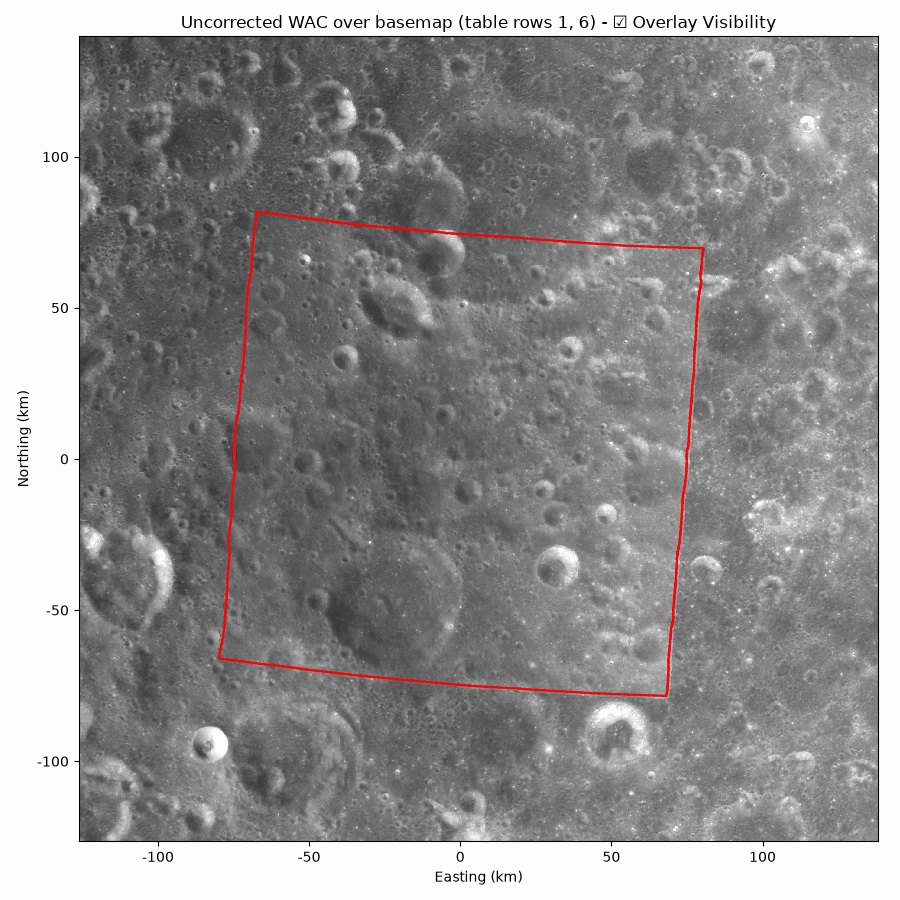

In [7]:
plotting.plot_overlay_toggle(basemap_path, wac_path, title="Uncorrected WAC over basemap (table rows 1, 6)")


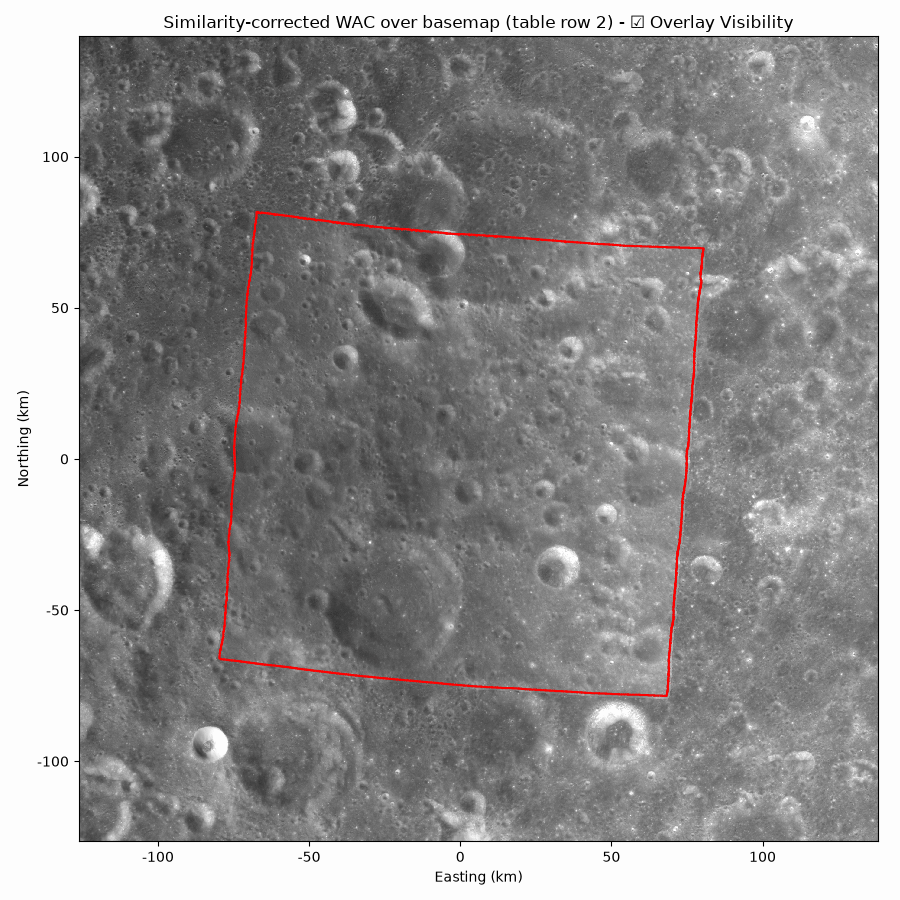

In [8]:
plotting.plot_overlay_toggle(
    basemap_path, corrected_similarity_path, title="Similarity-corrected WAC over basemap (table row 2)"
)


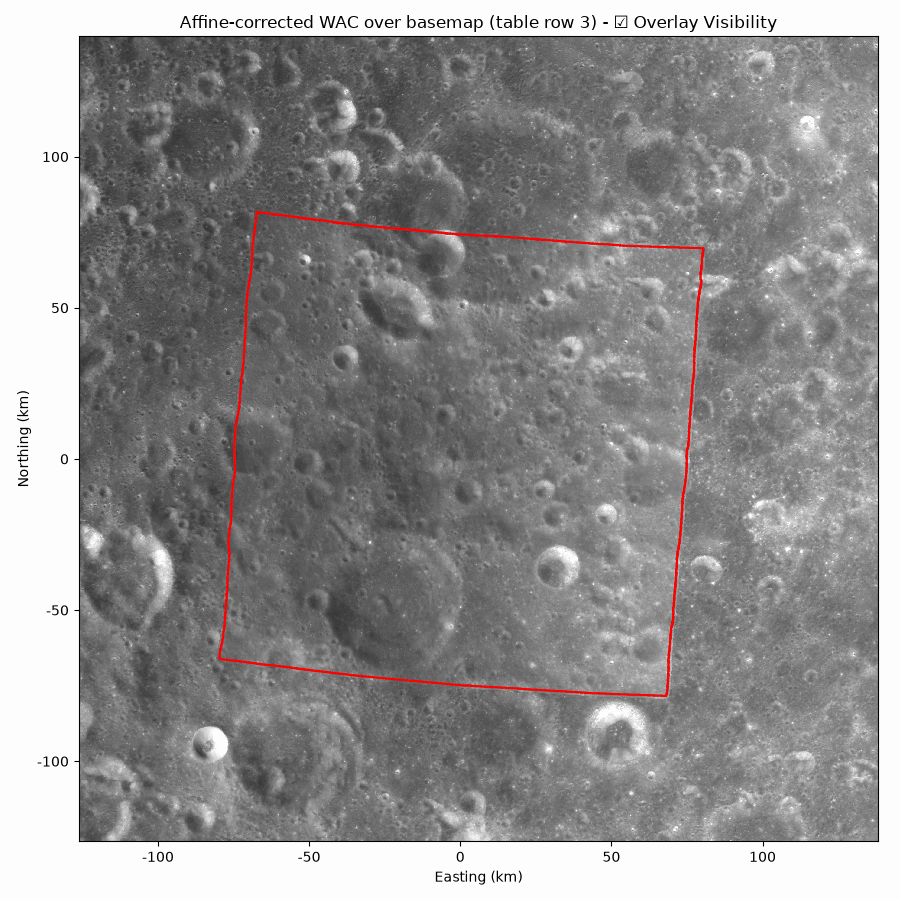

In [9]:
plotting.plot_overlay_toggle(
    basemap_path, corrected_affine_path, title="Affine-corrected WAC over basemap (table row 3)"
)


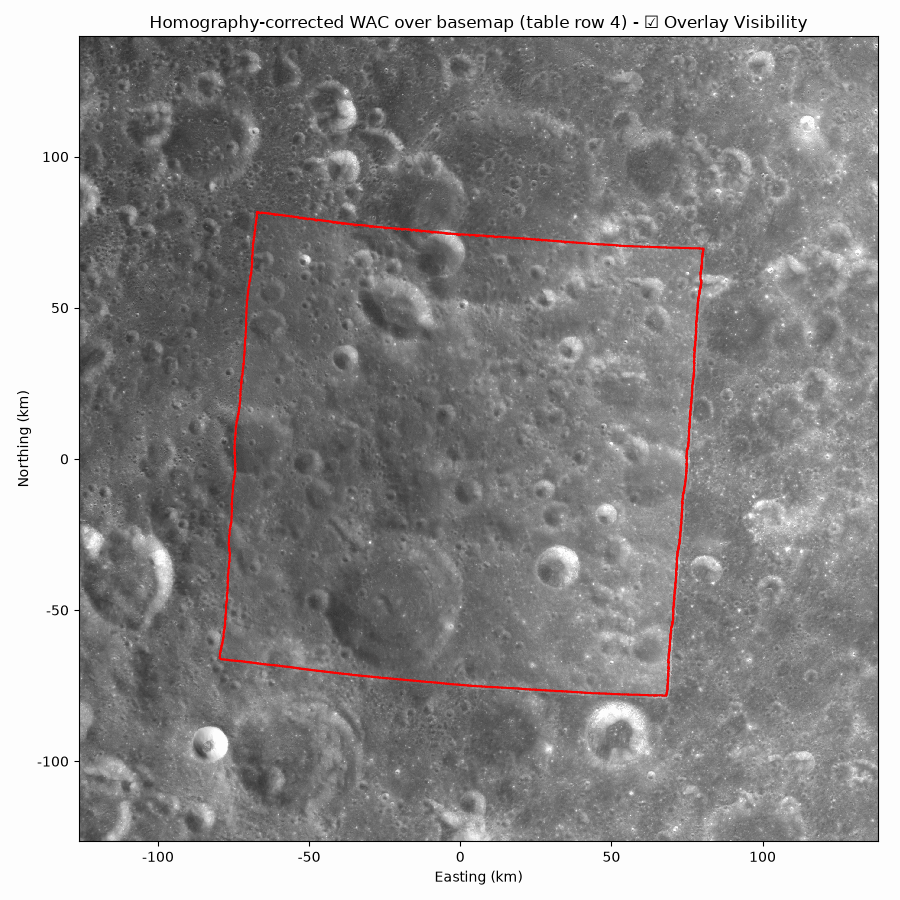

In [10]:
plotting.plot_overlay_toggle(
    basemap_path, corrected_homography_path, title="Homography-corrected WAC over basemap (table row 4)"
)

## A second matcher: LightGlue

`pose_alignment.match_features_lightglue` swaps classical SIFT for a deep-learned local-feature
extractor (DISK) + learned matcher -- real headroom for future shadowed/low-texture EDRs SIFT might
not find enough points on at all. Same inputs as SIFT above, same downstream homography fit (the
model already validated by direct user visual inspection as giving a real, non-noise improvement)
-- only the matcher differs, for a direct, apples-to-apples comparison against SIFT's own homography
result. **Table row 5.**

In [11]:
basemap_points_px_lg, wac_points_px_lg = pose_alignment.match_features_lightglue(
    basemap_image, basemap_valid, wac_image, wac_valid
)
print(f"SIFT:      {len(basemap_points_px)} matched points")
print(f"LightGlue: {len(basemap_points_px_lg)} matched points")

basemap_points_map_lg = pose_alignment.pixel_points_to_map(basemap_points_px_lg, basemap_transform)
wac_points_map_lg = pose_alignment.pixel_points_to_map(wac_points_px_lg, wac_transform)

homography_lg, inliers_homography_lg, residuals_homography_lg_m = pose_alignment.fit_homography_correction(
    wac_points_map_lg, basemap_points_map_lg
)
inlier_residuals_lg_m = residuals_homography_lg_m[inliers_homography_lg]
print(
    f"LightGlue homography: inliers {inliers_homography_lg.sum():3d}/{len(inliers_homography_lg)}   "
    f"residual mean {inlier_residuals_lg_m.mean():5.0f}m ({inlier_residuals_lg_m.mean() / target_gsd_m:.2f}px)"
)

results.append(
    {
        "row": 5,
        "projection": "2D->2D",
        "matcher": "LightGlue",
        "correction": "homography",
        "dof": 8,
        "n_points": len(inliers_homography_lg),
        "n_kept": int(inliers_homography_lg.sum()),
        "residual_mean_m": inlier_residuals_lg_m.mean(),
        "residual_max_m": inlier_residuals_lg_m.max(),
        "residual_mean_px": inlier_residuals_lg_m.mean() / target_gsd_m,
    }
)

SIFT:      316 matched points
LightGlue: 791 matched points
LightGlue homography: inliers 728/791   residual mean   140m (0.66px)



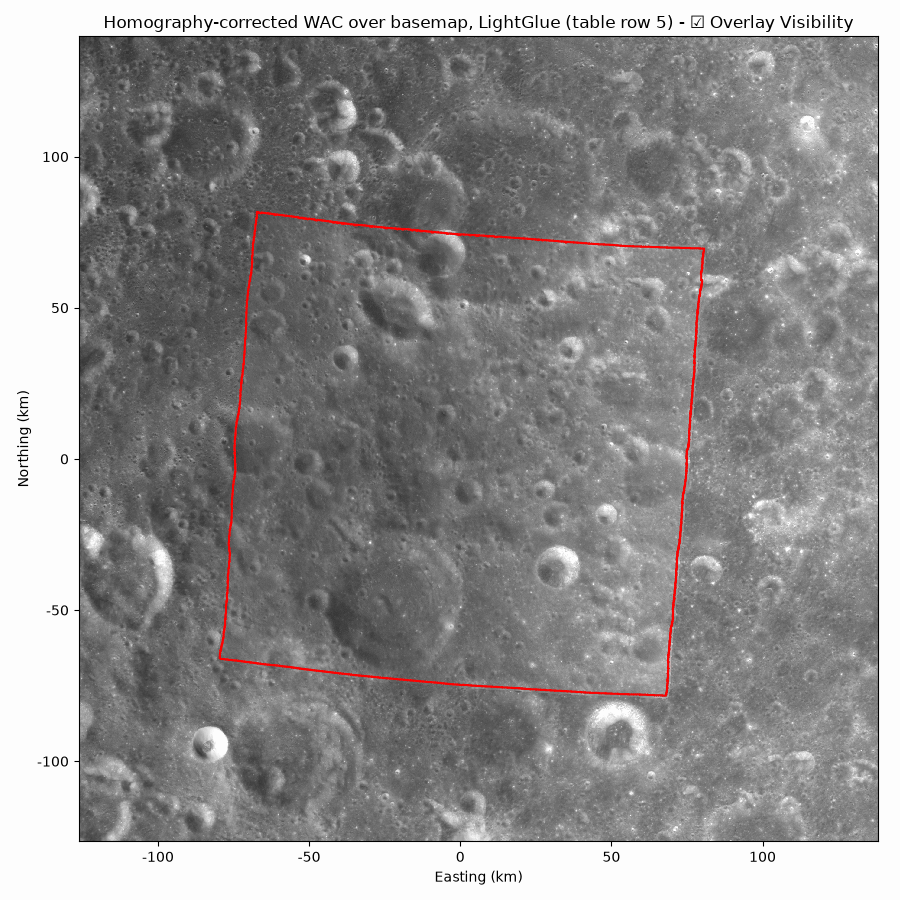

In [12]:
corrected_homography_lg_path = pose_alignment.apply_homography_correction(
    wac_path, homography_lg, alignment_dir / "wac_corrected_homography_lightglue.tif"
)
plotting.plot_overlay_toggle(
    basemap_path, corrected_homography_lg_path, title="Homography-corrected WAC over basemap, LightGlue (table row 5)"
)

## The 3D->2D approach: real ISIS control points, a real camera-pose correction

Everything above corrects the WAC raster's own map-space georeferencing after the fact -- a 2D fix,
not a camera-pose one. `control_network.resolve_control_points` converts the LightGlue match set
(more tie points than SIFT's) into real ISIS control points: for each match, the real image-space
pixel it was observed at in the *original*, pre-`cam2map` WAC crop cube, resolved through whatever
camera model `entry.crop_result` actually carries (ISIS's real DEM, by default, now) --
`isis_wac.resolve_ground_to_image_model` picks the right authority (native ISIS Pushframe model,
not CSM -- see its own docstring for why). The trusted ground truth (`ground_lonlat`) comes from
the basemap's own georeferencing at each match, `(lon, lat)` only, no elevation baked in yet.

In [13]:
ground_to_image_model = isis_wac.resolve_ground_to_image_model(
    entry.stitched, entry.crop_result, entry.per_image_config
)
with rasterio.open(wac_path) as src:
    map_crs = src.crs

observed_pixels, ground_lonlat = control_network.resolve_control_points(
    wac_points_map_lg, basemap_points_map_lg, map_crs, ground_to_image_model, entry.per_image_config
)
print(f"{len(observed_pixels)} real ISIS control points resolved (from {len(wac_points_map_lg)} LightGlue matches)")

resolve_control_points: dropped 299/791 tie points whose implied ground point doesn't project into the original crop
492 real ISIS control points resolved (from 791 LightGlue matches)


`ground_points_me_m`'s trusted 3D location must sample elevation from *the same* real DEM the
camera model above resolved through (`isis_wac.sample_lunar_dem_radii_batch` -- deliberately
camera-independent: a basemap point has no reason to be visible to *this* one camera's own view for
its elevation to be meaningful) -- see `control_network.py`'s own module docstring for why mixing
an elevation-aware ground truth with an elevation-unaware camera model (or vice versa) would
conflate real camera-pose error with a shape-model mismatch. Both sides are DEM-consistent here by
construction, since `entry.crop_result` already carries the DEM by default.

In [14]:
dem_radii_m = isis_wac.sample_lunar_dem_radii_batch(ground_lonlat, entry.per_image_config)
print(
    f"Sampled DEM radii: min {dem_radii_m.min():.0f}m, max {dem_radii_m.max():.0f}m, "
    f"mean {dem_radii_m.mean():.0f}m, std {dem_radii_m.std():.0f}m "
    f"(real, varying terrain, not a flat ellipsoid constant -- confirms the DEM is actually in effect)"
)
ground_points_me_m = (
    np.array(
        [
            tie_points.lonlat_to_ground_km(lon_deg, lat_deg, radius_m / 1000.0)
            for (lon_deg, lat_deg), radius_m in zip(ground_lonlat, dem_radii_m, strict=True)
        ]
    )
    * 1000.0
)

Sampled DEM radii: min 1737543m, max 1741608m, mean 1739561m, std 643m (real, varying terrain, not a flat ellipsoid constant -- confirms the DEM is actually in effect)


`wac_camera_model.py`'s hand-rolled forward projection stands in for `jigsaw`, which hit a real,
root-caused, unfixable bug in its PushFrame framelet search (see `docs/wac-jigsaw-investigation.md`
for the full trail). Its optics chain is validated to exact (0.000px) agreement with real `campt`
output, and its framelet search is validated to 0.00m ground error round-tripped through `campt`'s
trusted inverse.

In [15]:
with warnings.catch_warnings():
    # NotGeoreferencedWarning is expected for an ISIS .cub at this pipeline stage (no geotransform
    # yet, not a bug) -- see plotting.read_raster_band's own docstring for this same suppression.
    warnings.simplefilter("ignore", rasterio.errors.NotGeoreferencedWarning)
    with rasterio.open(entry.crop_result.cub_path) as src:
        n_lines = src.height
n_framelets = n_lines // wac_camera_model.FRAMELET_HEIGHT
et0, et_per_line = wac_camera_model.calibrate_et_per_crop_line(entry.crop_result.cub_path, n_lines)
print(f"crop: {n_framelets} framelets, et0={et0:.3f}, et_per_line={et_per_line:.6f}")

crop: 70 framelets, et0=625843678.222, et_per_line=-0.100446


**Table row 6: 3D->2D, LightGlue, uncorrected.** How far off the existing, uncorrected
SPICE-derived pose already is, at each real control point, projected through the DEM-shaped camera
model -- a direct before/after baseline for the fit below.

In [16]:
baseline_residuals_px = []
for ground_pt, obs in zip(ground_points_me_m, observed_pixels, strict=True):
    predicted = wac_camera_model.find_framelet_and_project(ground_pt, n_framelets, et0, et_per_line)
    if predicted is not None:
        baseline_residuals_px.append((predicted[0] - obs[0], predicted[1] - obs[1]))
baseline_residuals_px = np.array(baseline_residuals_px)
baseline_norms = np.linalg.norm(baseline_residuals_px, axis=1)
print(
    f"Baseline (uncorrected): {len(baseline_residuals_px)}/{len(observed_pixels)} points resolved, "
    f"residual mean {baseline_norms.mean():.2f}px, max {baseline_norms.max():.2f}px"
)

results.append(
    {
        "row": 6,
        "projection": "3D->2D",
        "matcher": "LightGlue",
        "correction": "uncorrected",
        "dof": 0,
        "n_points": len(observed_pixels),
        "n_kept": len(baseline_residuals_px),
        "residual_mean_m": baseline_norms.mean() * target_gsd_m,
        "residual_max_m": baseline_norms.max() * target_gsd_m,
        "residual_mean_px": baseline_norms.mean(),
    }
)

Baseline (uncorrected): 492/492 points resolved, residual mean 1.56px, max 7.66px


**Table row 7: 3D->2D, LightGlue, 6-DOF pose.** `fit_pose_correction` fits a single, frozen 6-DOF
`PoseCorrection` (3 position, meters, MOON_ME; 3 rotation, composed on the camera side -- matching
this project's own precedent that WAC-VIS's real boresight offset is frame-constant, not
time-varying) against the real control points, via `scipy.optimize.least_squares`.

In [17]:
fit = wac_camera_model.fit_pose_correction(ground_points_me_m, observed_pixels, n_framelets, et0, et_per_line)

fit_norms = np.linalg.norm(fit.residuals_px, axis=1)
# A control point that lands outside crop coverage under the fitted correction gets a fixed, large
# penalty residual (see fit_pose_correction's own docstring) -- filtered out here for the mean/max
# stats below since it's a sentinel, not a real pixel error; reported separately if it happens.
RESOLVED_RESIDUAL_THRESHOLD_PX = 100.0  # well below _UNRESOLVED_RESIDUAL_PX, well above any real fit
resolved = fit_norms < RESOLVED_RESIDUAL_THRESHOLD_PX
print(f"Fit success: {fit.success}")
print(f"delta_position_m (MOON_ME): {fit.correction.delta_position_m}")
rotvec_deg = np.degrees(Rotation.from_matrix(fit.correction.delta_rotation).as_rotvec())
print(f"delta_rotation (deg, camera-frame rotation vector): {rotvec_deg}")
print(
    f"Fitted: {resolved.sum()}/{len(observed_pixels)} points resolved, "
    f"residual mean {fit_norms[resolved].mean():.2f}px, max {fit_norms[resolved].max():.2f}px"
)
if not resolved.all():
    print(f"WARNING: {(~resolved).sum()} control point(s) unresolved at the fitted correction")

results.append(
    {
        "row": 7,
        "projection": "3D->2D",
        "matcher": "LightGlue",
        "correction": "6-DOF pose",
        "dof": 6,
        "n_points": len(observed_pixels),
        "n_kept": int(resolved.sum()),
        "residual_mean_m": fit_norms[resolved].mean() * target_gsd_m,
        "residual_max_m": fit_norms[resolved].max() * target_gsd_m,
        "residual_mean_px": fit_norms[resolved].mean(),
    }
)

Fit success: True
delta_position_m (MOON_ME): [ 1.09009156 -3.63307033 -1.22318179]
delta_rotation (deg, camera-frame rotation vector): [-0.0385938  -0.03554113  0.04321462]
Fitted: 492/492 points resolved, residual mean 1.41px, max 7.42px


## Results table

One row per (projection, matcher, correction) combination evaluated above -- same combinations as
the original investigation, just reported systematically instead of scattered prints. `n_points` is
the match/control-point set size feeding that row; `n_kept` is how many actually landed inside the
residual stats (RANSAC inliers for the 2D rows, successfully-projected/resolved points for the 3D
rows).

**Rows 6/7's `residual_max_m` sits well above their own `residual_mean_m`** -- confirmed (live
diagnostic, not guessed) that this is real, not a stale-ellipsoid product sneaking back in:
`dem_radii_m` for these control points varies genuinely (hundreds of meters of std, real terrain,
not a flat constant), and the handful of worst-residual points are exactly the ones sitting on the
*highest* real local elevation in this crop (+1.7km to +3.7km above the mean) -- consistent,
expected local-terrain complexity a single frozen 6-DOF rigid correction can't fully absorb, not a
bug. The 2D rows' own max residuals (2-4x their means) show the same ordinary pattern.

In [18]:
results_df = pd.DataFrame(results).set_index("row")
results_df

,projection,matcher,correction,dof,n_points,n_kept,residual_mean_m,residual_max_m,residual_mean_px
row,,,,,,,,,
1,2D->2D,SIFT,uncorrected,0,316,316,124.102197,423.046009,0.587302
2,2D->2D,SIFT,similarity,4,316,302,99.075139,389.366802,0.468864
3,2D->2D,SIFT,affine,6,316,300,97.680276,406.886568,0.462263
4,2D->2D,SIFT,homography,8,316,307,100.385704,288.978070,0.475066
5,2D->2D,LightGlue,homography,8,791,728,139.989607,299.503409,0.662488
6,3D->2D,LightGlue,uncorrected,0,492,492,329.594307,1619.668221,1.559774
7,3D->2D,LightGlue,6-DOF pose,6,492,492,297.374687,1566.950589,1.407298


## A direct visual before/after: the fitted 6-DOF correction, baked into a real corrected overlay

`isis_wac.apply_pose_correction_to_crop` bakes `fit.correction` into a *copy* of the crop cube's
cached `InstrumentPointing` (patching only its single, time-independent `ConstantRotation` matrix
-- see that function's own docstring and `docs/corrected-overlay-cam2map-plan.md` for the full
mechanism), so ISIS's own already-validated `cam2map` (`run_cam2map_for_crop`, completely
unmodified) picks up the corrected pose automatically. **Table row 7.**


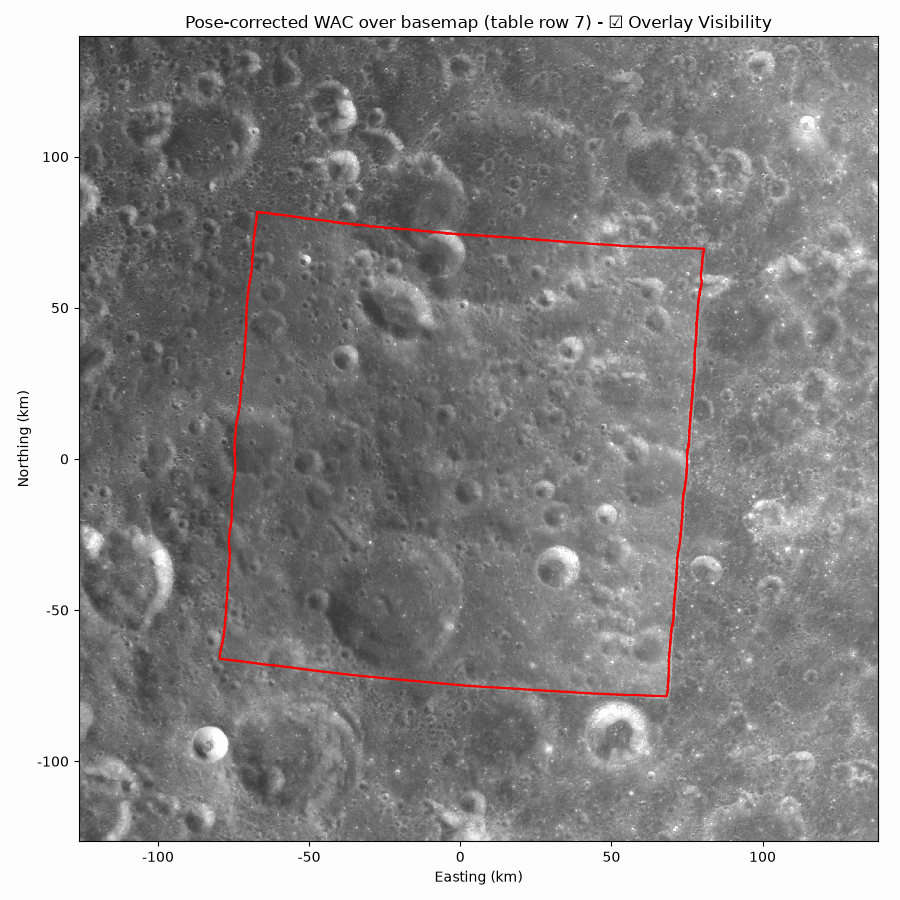

In [19]:
corrected_crop = isis_wac.apply_pose_correction_to_crop(entry.crop_result, fit.correction, entry.per_image_config)
corrected_cam2map_path = isis_wac.run_cam2map_for_crop(corrected_crop, entry.dem_ortho_result, entry.per_image_config)
plotting.plot_overlay_toggle(
    basemap_path, corrected_cam2map_path, title="Pose-corrected WAC over basemap (table row 7)"
)